# Infering payload properties of visual encodings with classifiers, without decoding

*Do visual encodings (QR, etc.) unintentionally act like weak randomness extractors, and what side-channel information about the payload leaks without decoding?*

## notebook setup


In [ ]:
!pip install segno

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 3.2 MB/s eta 0:00:00


In [ ]:
# imports
import segno
import math
import regex as re
from random import Random
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# modeling inputs
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

## generating payloads of different "classes"

In [ ]:
# Constants
PAYLOAD_LEN = 128  # bytes
ENCODING = "utf-8"

In [ ]:
def rng(seed):
    return Random(seed)

I create 4 different classes with these generators for payloads that will be encoded into a QR code. These will be the target labels of the models:

**C1**: constant character string

**C2**: periodic string, like "ABABABAB"

**C3**: english language text (full sentences), no punctuation

**C4**: random letters.

In [ ]:
def gen_constant(seed, length=PAYLOAD_LEN, **kwargs):
    return b"A" * length


def gen_periodic(seed, length=PAYLOAD_LEN, **kwargs):
    pattern = b"AB"
    reps = (length + len(pattern) - 1) // len(pattern)
    return (pattern * reps)[:length]


def load_corpus(path):
    with open(path, "r", encoding="ascii") as f:
        text = f.read()
    text = text.lower()
    text = re.sub(r"[^a-z ]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.encode("ascii")


def gen_english(seed, corpus_bytes, length=PAYLOAD_LEN, **kwargs):
    r = rng(seed)
    max_start = len(corpus_bytes) - length
    assert max_start > 0
    start = r.randint(0, max_start)
    return corpus_bytes[start:start + length]


def gen_random(seed, length=PAYLOAD_LEN, **kwargs):
    r = rng(seed)
    return bytes(r.getrandbits(8) for _ in range(length))

In [ ]:
GENERATORS = {
    "C1": gen_constant,
    "C2": gen_periodic,
    "C3": gen_english,
    "C4": gen_random,
}

In [ ]:
def make_seed(class_id, ec_level, index):
    return hash((class_id, ec_level, index)) & 0xffffffff

In [ ]:
def sanity(payload):
    assert isinstance(payload, bytes)
    assert len(payload) == PAYLOAD_LEN

In [ ]:
corpus_bytes = load_corpus("corpus_english.txt")

In [ ]:
def byte_entropy(b):
    counts = Counter(b)
    total = len(b)
    return -sum(
        (c/total) * math.log2(c/total)
        for c in counts.values()
    )

for cid in ["C1", "C2", "C3", "C4"]:
    seed = make_seed(cid, "L", 0)
    payload = GENERATORS[cid](seed=seed, corpus_bytes=corpus_bytes)
    print(cid, byte_entropy(payload))

C1 -0.0
C2 1.0
C3 3.946382446902645
C4 6.650352441389348


we see that truly random characters has the highest byte entropy score. English is still higher than periodic and constant, but still much lower than random (slightly unexpected)

## testing corpus for bias

frequency distribution

In [ ]:
counts = Counter(corpus_bytes)
total = len(corpus_bytes)

for b in sorted(counts):
    print(chr(b), counts[b], counts[b]/total)

  511 0.13836988897914973
a 251 0.06796642296236122
b 41 0.011102085025724344
c 143 0.03872190630923369
d 98 0.026536691037097212
e 395 0.10695911183319794
f 77 0.020850257243433524
g 67 0.018142431627403196
h 79 0.021391822366639588
i 256 0.06932033577037638
j 1 0.00027078256160303275
k 4 0.001083130246412131
l 137 0.03709721093961549
m 93 0.025182778229082048
n 259 0.07013268345518549
o 211 0.05713512049823991
p 75 0.020308692120227456
q 4 0.001083130246412131
r 226 0.06119685892228541
s 244 0.06607094503114
t 296 0.0801516382344977
u 100 0.027078256160303276
v 24 0.006498781478472786
w 28 0.007581911724884917
x 7 0.0018954779312212293
y 61 0.016517736257785
z 5 0.0013539128080151638


entropy

In [ ]:
entropy = byte_entropy(corpus_bytes)
print("Corpus entropy:", entropy)

Corpus entropy: 4.12350814300114


autocorrelation

In [ ]:
def autocorr(b, lag):
    b = np.array(list(b))
    return np.corrcoef(b[:-lag], b[lag:])[0,1]

for lag in range(1, 10):
    ac = autocorr(corpus_bytes, lag)
    print(f"Lag {lag}: {ac:.3f}")

Lag 1: -0.169
Lag 2: -0.137
Lag 3: 0.001
Lag 4: -0.046
Lag 5: 0.006
Lag 6: -0.057
Lag 7: -0.023
Lag 8: 0.011
Lag 9: 0.002


windowed entropy

In [ ]:
window_size = 128
entropies = []

for i in range(0, len(corpus_bytes) - window_size + 1, window_size):
    window = corpus_bytes[i:i+window_size]
    entropies.append(byte_entropy(window))

print("Mean window entropy:", np.mean(entropies))
print("Std window entropy:", np.std(entropies))

Mean window entropy: 4.0007899825178965
Std window entropy: 0.07587855297676765


## generating each class of qr code with signo (making qr dataset)

In [ ]:
def encode_qr(payload: bytes, ec_level="L", version=6, mask=0):
    """
    Encode payload into QR code and return 2D numpy array (0=white,1=black)
    """
    # Segno expects str or bytes
    qr = segno.make(payload, error=ec_level, version=version, mask=mask, boost_error=False)

    # Extract module matrix (True=black, False=white)
    matrix = np.array(qr.matrix, dtype=int)
    return matrix

In [ ]:
dataset = []

for class_id in ["C1", "C2", "C3", "C4"]:
    for ec_level in ["L", "M", "Q", "H"]:
        for i in range(500):  # sample count per condition
            seed = make_seed(class_id, ec_level, i)
            payload = GENERATORS[class_id](seed=seed, corpus_bytes=corpus_bytes)
            sanity(payload)

            # encode QR
            matrix = encode_qr(payload, ec_level=ec_level, version=11)

            # store dataset entry
            dataset.append({
                "sample_id": f"{class_id}_{ec_level}_{i}",
                "matrix": matrix,
                "payload_class": class_id,
                "error_correction": ec_level
            })

In [ ]:
np.savez_compressed("qr_dataset.npz",
    sample_ids=[d["sample_id"] for d in dataset],
    matrices=np.array([d["matrix"] for d in dataset]),
    classes=[d["payload_class"] for d in dataset],
    ec_levels=[d["error_correction"] for d in dataset]
)

visualizing the "mean qr code" of each class

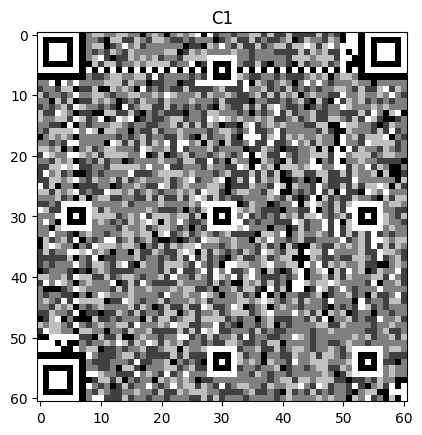

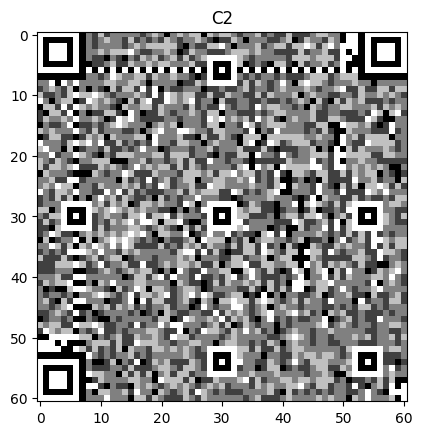

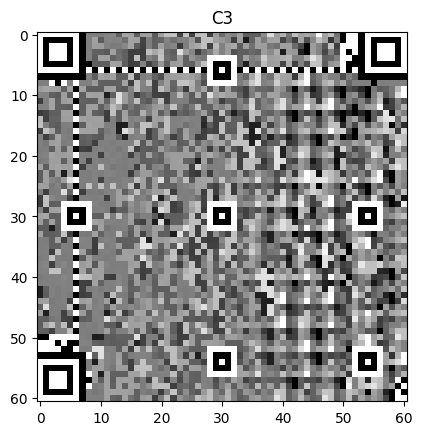

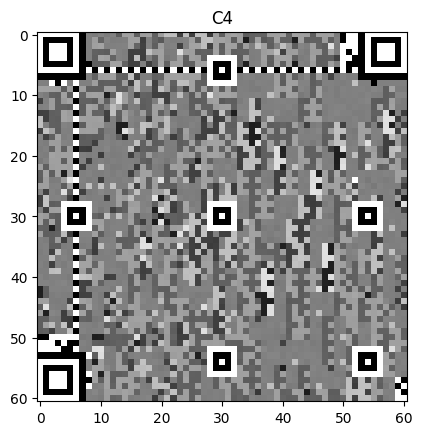

In [ ]:
for cid in ["C1","C2","C3","C4"]:
    class_matrices = np.array([d["matrix"] for d in dataset if d["payload_class"]==cid])
    plt.imshow(class_matrices.mean(axis=0), cmap="gray")
    plt.title(cid)
    plt.show()

we note that there are LARGE differences per class. random is the most grey (barely any pixel is almost ALWAYS white or always black). This makes sense as there is no pattern. Constant and periodic have more squares that are closer to black and white. Even though QR codes de-localize text patterns, the uniformity of the string still shows through.

Surprisingly, the english text results in a localized area of pattern.

In [ ]:
def per_module_stats(dataset, stripped=True):
    matrices = np.array([d['stripped_matrix'] if stripped else d['matrix'] for d in dataset])
    mean_matrix = matrices.mean(axis=0)
    var_matrix = matrices.var(axis=0)
    return mean_matrix, var_matrix

In [ ]:
def strip_qr(matrix):
    mat = matrix.copy()
    # finder patterns (top-left, top-right, bottom-left)
    mat[0:7,0:7] = 0
    mat[0:7,-7:] = 0
    mat[-7:,0:7] = 0
    # timing patterns (row 6, col 6)
    mat[6, :] = 0
    mat[:, 6] = 0
    # alignment patterns (v11)
    mat[-9:-4,-9:-4] = 0
    return mat

# apply to all dataset samples
for d in dataset:
    d['stripped_matrix'] = strip_qr(d['matrix'])

In [ ]:
# convert to arrays
X = np.array([d['stripped_matrix'] for d in dataset])
y = np.array([d['payload_class'] for d in dataset])

# map classes to integers
class_map = {"C1":0, "C2":1, "C3":2, "C4":3}
y = np.array([class_map[c] for c in y])

# add channel dimension for CNN (H, W, 1)
X = X[:, :, :, np.newaxis].astype(np.float32)
X = np.transpose(X, (0, 3, 1, 2))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## 1st model is a simple CNN, and we only pass the raw pixels to train.

In [ ]:
# X_train, X_test are now (N,1,H,W)
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test))


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

class SimpleQRNet(nn.Module):
    def __init__(self, input_height, input_width):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # compute flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_height, input_width)
            feat = self.conv(dummy)
            flattened_size = feat.numel()  # total elements
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )
    def forward(self, x):
        return self.fc(self.conv(x))


input_height, input_width = X_train.shape[2], X_train.shape[3]
model = SimpleQRNet(input_height, input_width)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(5):  # start simple
    model.train()
    running_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.1247
Epoch 2, Loss: 0.0001
Epoch 3, Loss: 0.0000
Epoch 4, Loss: 0.0000
Epoch 5, Loss: 0.0000


eval

In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
print("Test Accuracy:", correct/total)

Test Accuracy: 1.0


This first-pass CNN baseline works perfectly. This confirms that raw module patterns already carry enough info to distinguish payload classes. This is expected.

## feature abelation with basic cnn

*if we vary what the model recieves (FFT features, row/col entropy, flattened pixels, cropped regions), what happens to its accuracy?*

In [ ]:
def row_col_entropy(matrix):
    """Compute normalized row and column entropies."""
    H, W = matrix.shape
    row_ent = np.zeros(H)
    col_ent = np.zeros(W)
    for i in range(H):
        vals, counts = np.unique(matrix[i], return_counts=True)
        probs = counts / counts.sum()
        row_ent[i] = -np.sum(probs * np.log2(probs))
    for j in range(W):
        vals, counts = np.unique(matrix[:, j], return_counts=True)
        probs = counts / counts.sum()
        col_ent[j] = -np.sum(probs * np.log2(probs))
    return np.concatenate([row_ent, col_ent])

In [ ]:
def fft_features(matrix):
    fft_mat = np.fft.fft2(matrix)
    fft_mag = np.abs(np.fft.fftshift(fft_mat))
    return fft_mag.flatten()

In [ ]:
def crop_region(matrix, top, left, size=20):
    return matrix[top:top+size, left:left+size]

In [ ]:
# -----------------------
# Prepare dataset
# -----------------------

# Convert stripped matrices to numpy
X_raw = np.array([d['stripped_matrix'] for d in dataset])
y = np.array([class_map[d['payload_class']] for d in dataset])

# Split train/test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------
# Compute feature sets
# -----------------------

# 1. Raw pixels (flattened)
X_train_flat = X_train_raw.reshape(len(X_train_raw), -1)
X_test_flat  = X_test_raw.reshape(len(X_test_raw), -1)

# 2. Row/col entropy
X_train_entropy = np.array([row_col_entropy(m) for m in X_train_raw])
X_test_entropy  = np.array([row_col_entropy(m) for m in X_test_raw])

# 3. FFT features
X_train_fft = np.array([fft_features(m) for m in X_train_raw])
X_test_fft  = np.array([fft_features(m) for m in X_test_raw])

# 4. Cropped regions (example: top-left 20x20)
X_train_crop = np.array([crop_region(m, 0, 0, 20) for m in X_train_raw])
X_test_crop  = np.array([crop_region(m, 0, 0, 20) for m in X_test_raw])

In [ ]:
def train_eval(X_tr, X_te, y_tr, y_te, name):
    clf = MLPClassifier(hidden_layer_sizes=(128,), max_iter=100, random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"{name} accuracy: {acc:.4f}")

In [ ]:
train_eval(X_train_flat, X_test_flat, y_train, y_test, "Raw pixels (flattened)")

Raw pixels (flattened) accuracy: 1.0000


In [ ]:
train_eval(X_train_entropy, X_test_entropy, y_train, y_test, "Row+Col entropy")

Row+Col entropy accuracy: 0.9931


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
train_eval(X_train_fft, X_test_fft, y_train, y_test, "FFT features")

FFT features accuracy: 0.9994


In [ ]:
# @TODO:fix this
train_eval(X_train_crop, X_test_crop, y_train, y_test, "Top-left crop 20x20")

## varying the dataset to include more patterns, different payload lengths, entropy levels, EC levels

In [ ]:
# Parameters
N_SEEDS = 200  # seeds per class, increased from 50
EC_LEVELS = ['L', 'M', 'Q', 'H']
PAYLOAD_LEN = 12

In [ ]:
def make_seed(class_id, ec_level, index):
    return hash((class_id, ec_level, index)) & 0xffffffff

In [ ]:
# Generate full dataset
dataset_diverse = []
for cid in ["C1","C2","C3","C4"]:
    for ec in EC_LEVELS:
        for idx in range(N_SEEDS):
            seed = make_seed(cid, ec, idx)
            # generate payload
            if cid == "C1":
                payload = b"A" * PAYLOAD_LEN
            elif cid == "C2":
                pattern = b"AB"
                reps = (PAYLOAD_LEN + len(pattern) - 1) // len(pattern)
                payload = (pattern * reps)[:PAYLOAD_LEN]
            elif cid == "C3":
                r = rng(seed)
                max_start = len(corpus_bytes) - PAYLOAD_LEN
                start = r.randint(0, max_start)
                payload = corpus_bytes[start:start+PAYLOAD_LEN]
            else:
                r = rng(seed)
                payload = bytes(r.getrandbits(8) for _ in range(PAYLOAD_LEN))
            # encode QR (version 11)
            qr = segno.make(payload, error=ec, version=11, micro=False)
            mat = np.array(qr.matrix, dtype=np.uint8)
            # strip fixed patterns
            mat_s = strip_qr(mat)
            dataset_diverse.append({
                'payload_class': cid,
                'ec_level': ec,
                'seed': seed,
                'matrix': mat,
                'stripped_matrix': mat_s
            })

print("Diverse dataset size:", len(dataset_diverse))

Diverse dataset size: 3200


In [ ]:
# Convert stripped matrices to tensor, reorder for PyTorch
X = np.array([d['stripped_matrix'] for d in dataset_diverse])
y = np.array([{"C1":0,"C2":1,"C3":2,"C4":3}[d['payload_class']] for d in dataset_diverse])

X = X[:, np.newaxis, :, :].astype(np.float32)  # (N, 1, H, W)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_dataset  = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)

# CNN with dynamic linear size
class SimpleQRNet(nn.Module):
    def __init__(self, h, w):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # compute flattened size dynamically
        with torch.no_grad():
            dummy = torch.zeros(1,1,h,w)
            feat = self.conv(dummy)
            flattened_size = feat.numel()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )
    def forward(self, x):
        return self.fc(self.conv(x))

h, w = X_train.shape[2], X_train.shape[3]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleQRNet(h, w).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(5):
    model.train()
    running_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
print("Raw CNN Test Accuracy:", correct/total)

Epoch 1, Loss: 0.5586
Epoch 2, Loss: 0.2442
Epoch 3, Loss: 0.0915
Epoch 4, Loss: 0.0289
Epoch 5, Loss: 0.0141
Raw CNN Test Accuracy: 0.9765625


In [ ]:
# Row+Col entropy
def row_col_entropy(matrix):
    H, W = matrix.shape
    row_ent = np.zeros(H)
    col_ent = np.zeros(W)
    for i in range(H):
        vals, counts = np.unique(matrix[i], return_counts=True)
        probs = counts / counts.sum()
        row_ent[i] = -np.sum(probs * np.log2(probs + 1e-9))
    for j in range(W):
        vals, counts = np.unique(matrix[:, j], return_counts=True)
        probs = counts / counts.sum()
        col_ent[j] = -np.sum(probs * np.log2(probs + 1e-9))
    return np.concatenate([row_ent, col_ent])

# FFT features
def fft_features(matrix):
    fft_mat = np.fft.fft2(matrix)
    fft_mag = np.abs(np.fft.fftshift(fft_mat))
    return fft_mag.flatten()

# Top-left crop 20x20
def crop_region(matrix, top=0, left=0, size=20):
    return matrix[top:top+size, left:left+size].flatten()

# Prepare feature matrices
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)
X_train_entropy = np.array([row_col_entropy(m[0]) for m in X_train])
X_test_entropy  = np.array([row_col_entropy(m[0]) for m in X_test])
X_train_fft = np.array([fft_features(m[0]) for m in X_train])
X_test_fft  = np.array([fft_features(m[0]) for m in X_test])
X_train_crop = np.array([crop_region(m[0]) for m in X_train])
X_test_crop  = np.array([crop_region(m[0]) for m in X_test])

# MLP training & evaluation
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def train_eval(X_tr, X_te, y_tr, y_te, name):
    clf = MLPClassifier(hidden_layer_sizes=(128,), max_iter=100, random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"{name} Test Accuracy: {acc:.4f}")

train_eval(X_train_flat, X_test_flat, y_train, y_test, "Raw pixels")
train_eval(X_train_entropy, X_test_entropy, y_train, y_test, "Row+Col entropy")
train_eval(X_train_fft, X_test_fft, y_train, y_test, "FFT features")
train_eval(X_train_crop, X_test_crop, y_train, y_test, "Top-left crop 20x20")


Raw pixels Test Accuracy: 0.9922


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Row+Col entropy Test Accuracy: 0.5219


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


FFT features Test Accuracy: 0.9906
Top-left crop 20x20 Test Accuracy: 0.8078


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


## takeaways

### summary of results

Do visual encodings (QR, etc.) unintentionally act like weak randomness extractors, and what side‑channel information about the payload leaks without decoding?

We can break this down into 2 parts / subquestions

1.   Do they extract / expose structure from the payload without decoding?
2.  What kind of information leaks, and how robust is it?


---

We demonstrated that yes, QR codes leak payload class information without decoding.

Our model never decodes the QR, it only sees module-level visual structure. Yet it can classify payload type (constant / periodic / English / random).


### our new understanding of how QR codes work

High-level structure survives encoding

Local regions contain partial information

Global structure aggregates to near-perfect classification

That is exactly the definition of a weak extractor:

It mixes information spatially, but does not eliminate higher-order correlations.


So, QR encoding partially diffuses payload structure but does not decorrelate it.